<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Assignment_05_Casestudy_2_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ICT_AI_ML_ Assignment 05_Casestudy_2_unsupervised learning

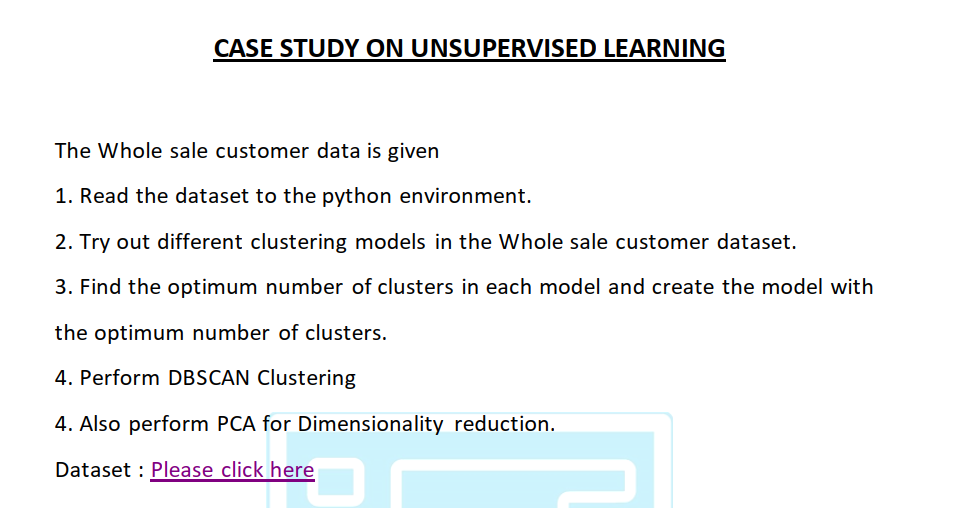

https://drive.google.com/file/d/1of8j1RupWB7eOucpXrzBg7BrlS3UuKuA/view

# 1. Importing Liabraries

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Loading the data file

In [173]:
df=pd.read_csv('/content/Wholesale customers data.csv')

# 3. Checking the first 10 rows

In [174]:
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


# 4. Finding the shape of the dataframe

In [175]:
df.shape

(440, 8)

#5. Summary statistics of the dataframe

In [176]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


# 6. Summary of the dataframe

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


# 7. Checking for null values

In [178]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


No null values

# 8. Checking for outliers

<Axes: >

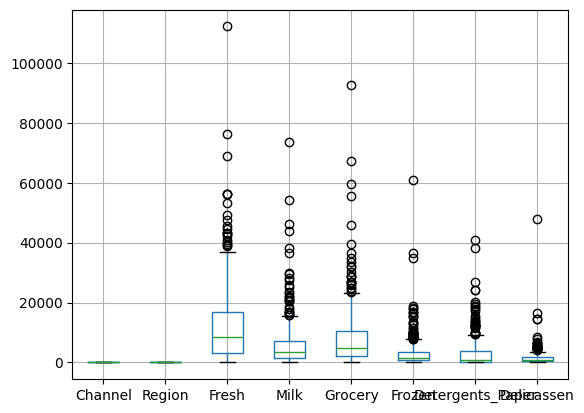

In [179]:
df.boxplot()

##Unsupervised Learning

In [180]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [181]:
x=df[['Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen']]

### Channel and Region is dropped

# 9.Applying standar scaling to the data

In [182]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#x_scaled = scaler.fit_transform(x)

# 9. Using KMeans clustering

In [183]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  km=KMeans(n_clusters=i,n_init=10)
  km.fit(x)
  css=km.inertia_  # this will give wcss score
  wcss.append(css)

In [184]:
wcss

[157595857165.60883,
 113217528520.90987,
 80332413843.01633,
 64855545528.21104,
 53116919400.737076,
 47692032997.07322,
 41158638815.569534,
 36287047175.02926,
 32848822250.353516,
 30182206218.09629]

# 10. Elbow method to find the optimum number of cluster

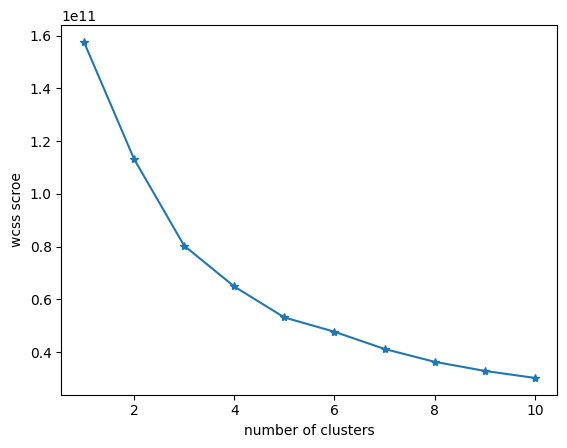

In [185]:
plt.plot(range(1,11),wcss,'-*')
plt.xlabel('number of clusters')
plt.ylabel('wcss scroe')
plt.show()

### seems like the number of cluster is 3


In [186]:
km=KMeans(n_clusters=3,n_init=10)
km.fit(x)

KMeans(n_clusters=3, n_init=10)

In [187]:
cluster_labels=km.predict(x)

In [188]:
cluster_labels

array([0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       2, 1, 2, 0, 0, 0, 1, 2, 0, 0, 0, 2, 0, 0, 2, 0, 1, 2, 2, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 2, 0, 2, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2,
       0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 1, 1, 2, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 2, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [189]:
pd.Series(cluster_labels).value_counts()

,count
0,329
2,60
1,51


# 11. Plotting region vs Fresh

In [190]:
df['cluster_labels']=cluster_labels

In [191]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster_labels
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,2


In [192]:
df['Channel'].value_counts()

,count
Channel,
1,298
2,142


In [193]:
df['Region'].value_counts()

,count
Region,
3,316
1,77
2,47


In [194]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen', 'cluster_labels'],
      dtype='object')

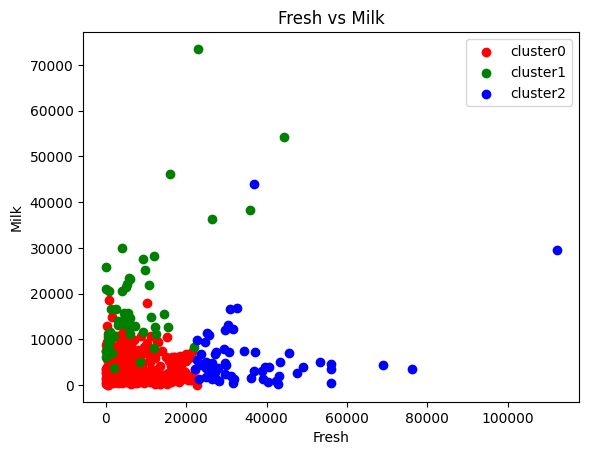

In [195]:
colors=['r','g','b']

for i in range(max(cluster_labels)+1):
  cluster_data=x[cluster_labels==i]
  plt.scatter(cluster_data['Fresh'],
              cluster_data['Milk'],
              c=colors[i],
              label=f'cluster{i}')
plt.legend()
plt.xlabel('Fresh')
plt.ylabel('Milk')
plt.title('Fresh vs Milk')
plt.show()

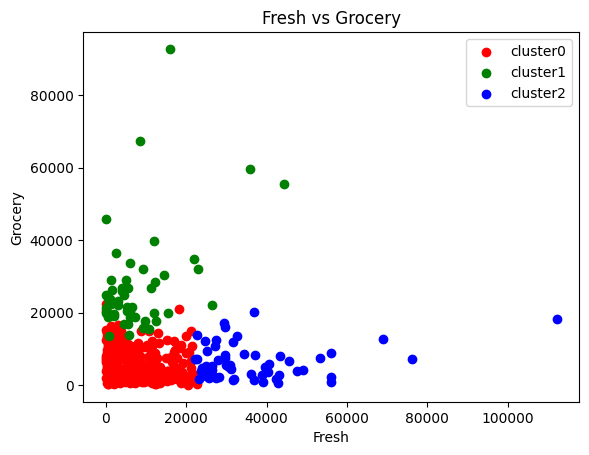

In [196]:
colors=['r','g','b']

for i in range(max(cluster_labels)+1):
  cluster_data=x[cluster_labels==i]
  plt.scatter(cluster_data['Fresh'],
              cluster_data['Grocery'],
              c=colors[i],
              label=f'cluster{i}')
plt.legend()
plt.xlabel('Fresh')
plt.ylabel('Grocery')
plt.title('Fresh vs Grocery')
plt.show()

# 12.silhoutte score

In [197]:
# silhoutte score
from sklearn.metrics import silhouette_score

In [198]:
# KMeans
silhouette_avg=silhouette_score(x,cluster_labels)
print(silhouette_avg)

0.47701791423660755


# 13. PCA

In [199]:
x.corr()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368
Grocery,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497
Frozen,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947
Detergents_Paper,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291
Delicassen,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000


## Scaling before PCA

In [200]:
from sklearn.preprocessing import scale
scale(x)

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       ...,
       [ 0.20032554,  1.31467078,  2.34838631, -0.54337975,  2.51121768,
         0.12145607],
       [-0.13538389, -0.51753572, -0.60251388, -0.41944059, -0.56977032,
         0.21304614],
       [-0.72930698, -0.5559243 , -0.57322717, -0.62009417, -0.50488752,
        -0.52286938]])

In [201]:
x=pd.DataFrame(scale(x),index=x.index,columns=x.columns)

In [202]:
x

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347
...,...,...,...,...,...,...
435,1.401312,0.848446,0.850760,2.075222,-0.566831,0.241091
436,2.155293,-0.592142,-0.757165,0.296561,-0.585519,0.291501
437,0.200326,1.314671,2.348386,-0.543380,2.511218,0.121456
438,-0.135384,-0.517536,-0.602514,-0.419441,-0.569770,0.213046


In [203]:
from sklearn.decomposition import PCA
pc=PCA()
pc_array=pc.fit_transform(x)

In [204]:
pc_array

array([[ 0.19329055, -0.30509996,  0.14087845, -0.48643154,  0.49528148,
        -0.00741414],
       [ 0.4344199 , -0.32841262, -0.31900662, -0.17883036,  0.36557931,
         0.05457185],
       [ 0.81114323,  0.8150957 , -1.52341562, -1.25408154, -0.37905353,
        -0.27753858],
       ...,
       [ 3.46570362, -1.03983801,  0.71316141,  0.0334078 , -0.53876786,
        -0.08534909],
       [-0.91802273, -0.03004659, -0.25840805, -0.52457824, -0.09321487,
        -0.028943  ],
       [-1.10513709, -0.86133787, -0.30515404, -0.11437678,  0.10990335,
         0.02897846]])

In [206]:
pc_array=pd.DataFrame(pc_array,columns=['PC1','PC2','PC3','PC4','PC5','PC6'])

In [207]:
pc_array

,PC1,PC2,PC3,PC4,PC5,PC6
0,0.193291,-0.305100,0.140878,-0.486432,0.495281,-0.007414
1,0.434420,-0.328413,-0.319007,-0.178830,0.365579,0.054572
2,0.811143,0.815096,-1.523416,-1.254082,-0.379054,-0.277539
3,-0.778648,0.652754,-0.163012,0.380060,-0.276138,0.060718
4,0.166287,1.271434,-0.066279,-0.826227,-0.394211,-0.026825
...,...,...,...,...,...,...
435,0.870602,2.220845,0.605500,1.049263,0.423781,0.869495
436,-0.902520,1.676916,1.418980,-0.572274,-0.257026,-0.226535
437,3.465704,-1.039838,0.713161,0.033408,-0.538768,-0.085349
438,-0.918023,-0.030047,-0.258408,-0.524578,-0.093215,-0.028943


In [221]:
pc1=PCA(n_components=2)
pc_array1=pc1.fit_transform(x)

In [222]:
pc_array1

array([[ 1.93290546e-01, -3.05099963e-01],
       [ 4.34419896e-01, -3.28412623e-01],
       [ 8.11143234e-01,  8.15095701e-01],
       [-7.78647832e-01,  6.52753734e-01],
       [ 1.66287259e-01,  1.27143372e+00],
       [-1.56169932e-01, -2.95140988e-01],
       [-3.35288404e-01, -5.25003258e-01],
       [ 1.40586434e-01, -2.30992687e-01],
       [-5.17319541e-01, -6.59362827e-01],
       [ 1.59210908e+00, -7.41011332e-01],
       [ 6.38085945e-01, -4.01825201e-01],
       [-9.27692579e-01, -2.19287242e-01],
       [ 9.91362176e-01,  6.85910808e-01],
       [ 8.50246760e-01, -8.56919642e-02],
       [ 8.45043794e-01,  1.54724325e-01],
       [-9.51585375e-01, -4.95908498e-01],
       [ 5.57558717e-01, -1.02612272e+00],
       [-3.52538598e-01,  2.07075910e-01],
       [ 3.16578563e-01,  4.42066292e-01],
       [-3.23755737e-01, -7.03586946e-01],
       [-3.20000597e-01,  1.56628147e-01],
       [-1.11844720e+00, -2.30527519e-01],
       [-1.76694545e-01,  2.14371699e+00],
       [ 4.

In [223]:
pc_array1 = pd.DataFrame(pc_array,columns = ['PC1','PC2'])

In [224]:
pc_array1.corr().round()

,PC1,PC2
PC1,1.0,-0.0
PC2,-0.0,1.0


In [225]:
pc.explained_variance_ratio_

array([0.44082893, 0.283764  , 0.12334413, 0.09395504, 0.04761272,
       0.01049519])

# 14. DB Scan

In [231]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=1.5, min_samples=5)
clusters=dbscan.fit_predict(x)

In [232]:
clusters

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,
        0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1, -1, -1,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [233]:
df['DBSCAN_Cluster'] = clusters

In [234]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

In [235]:
silhouette = silhouette_score(x, clusters) if n_clusters > 1 else None
print(f"Number of clusters (excluding noise): {n_clusters}")
print(f"Silhouette Score: {silhouette}")

Number of clusters (excluding noise): 1
Silhouette Score: None


In [236]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(x)

In [237]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(x)

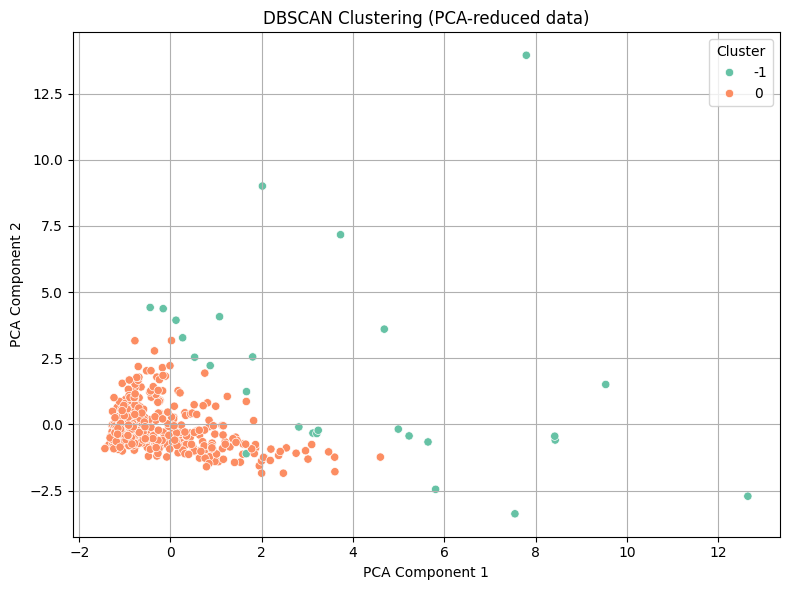

In [238]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1], hue=clusters, palette='Set2')
plt.title('DBSCAN Clustering (PCA-reduced data)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()